In [15]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.rcParams['font.family'] = 'Tahoma'
# If you have Thai fonts installed on your machine, you can set it here:
# plt.rcParams['font.family'] = 'Tahoma' 

# Load the clean datasets
# Note: Adjust the path if your notebook is in a different folder
path = '../data/clean_data/'

station_df = pd.read_csv(f'{path}5_18_station.csv', encoding='utf-8-sig')
votes_df = pd.read_csv(f'{path}5_18_votes.csv', encoding='utf-8-sig')
party_station_df = pd.read_csv(f'{path}5_18_party_station.csv', encoding='utf-8-sig')
party_votes_df = pd.read_csv(f'{path}5_18_party_vote.csv', encoding='utf-8-sig')

print("Data loaded successfully!")
print(f"Constituency Stations: {len(station_df)}")
print(f"Constituency Votes: {len(votes_df)}")

Data loaded successfully!
Constituency Stations: 306
Constituency Votes: 2066


In [16]:
# Calculate Total Turnout for the Constituency
total_eligible = station_df['eligible_voters'].sum()
total_present = station_df['voters_present'].sum()
turnout_rate = (total_present / total_eligible) * 100

print(f"--- Constituency Overview ---")
print(f"Total Eligible Voters: {total_eligible:,.0f}")
print(f"Total Voters Present: {total_present:,.0f}")
print(f"Overall Turnout Rate: {turnout_rate:.2f}%\n")

# Ballot Health (Spoiled & No Vote Ratios)
total_used = station_df['ballots_used'].sum()
spoiled_rate = (station_df['ballots_spoiled'].sum() / total_used) * 100
no_vote_rate = (station_df['ballots_no_vote'].sum() / total_used) * 100

print(f"Spoiled Ballot Rate: {spoiled_rate:.2f}%")
print(f"No Vote Rate: {no_vote_rate:.2f}%")

--- Constituency Overview ---
Total Eligible Voters: 112,789
Total Voters Present: 77,700
Overall Turnout Rate: 68.89%

Spoiled Ballot Rate: 6.95%
No Vote Rate: 0.05%


C:\Users\User\AppData\Local\Temp\ipykernel_29856\3937478731.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subdistrict_stats, x='turnout_pct', y='subdistrict', palette='viridis')


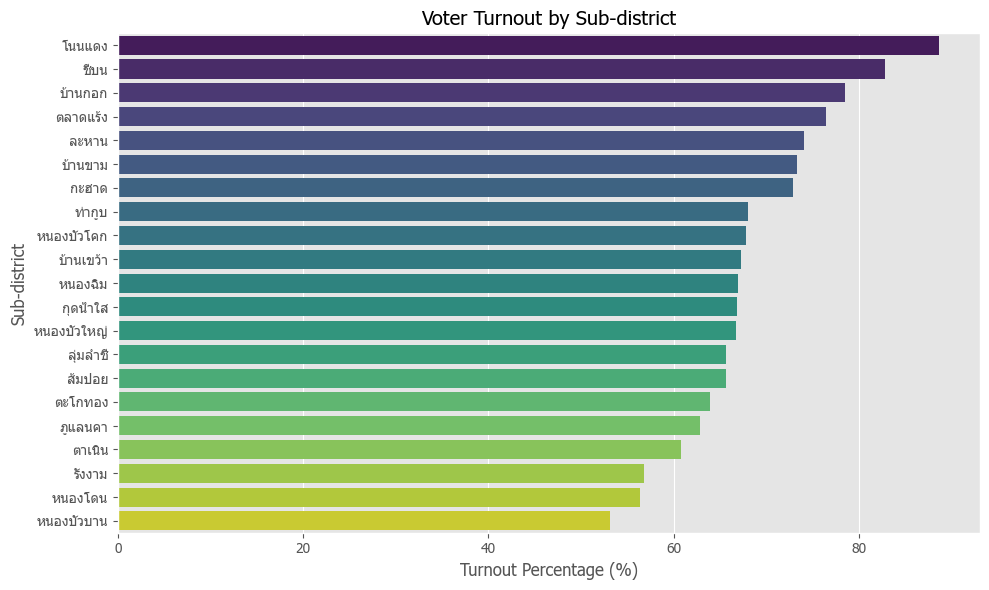

In [17]:
# Group by sub-district to see turnout variations
subdistrict_stats = station_df.groupby('subdistrict').agg({
    'eligible_voters': 'sum',
    'voters_present': 'sum'
}).reset_index()

subdistrict_stats['turnout_pct'] = (subdistrict_stats['voters_present'] / subdistrict_stats['eligible_voters']) * 100
subdistrict_stats = subdistrict_stats.sort_values(by='turnout_pct', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=subdistrict_stats, x='turnout_pct', y='subdistrict', palette='viridis')
plt.title('Voter Turnout by Sub-district')
plt.xlabel('Turnout Percentage (%)')
plt.ylabel('Sub-district')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_29856\3308234782.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=candidate_totals, x='votes', y='entity_name', palette='Blues_r')


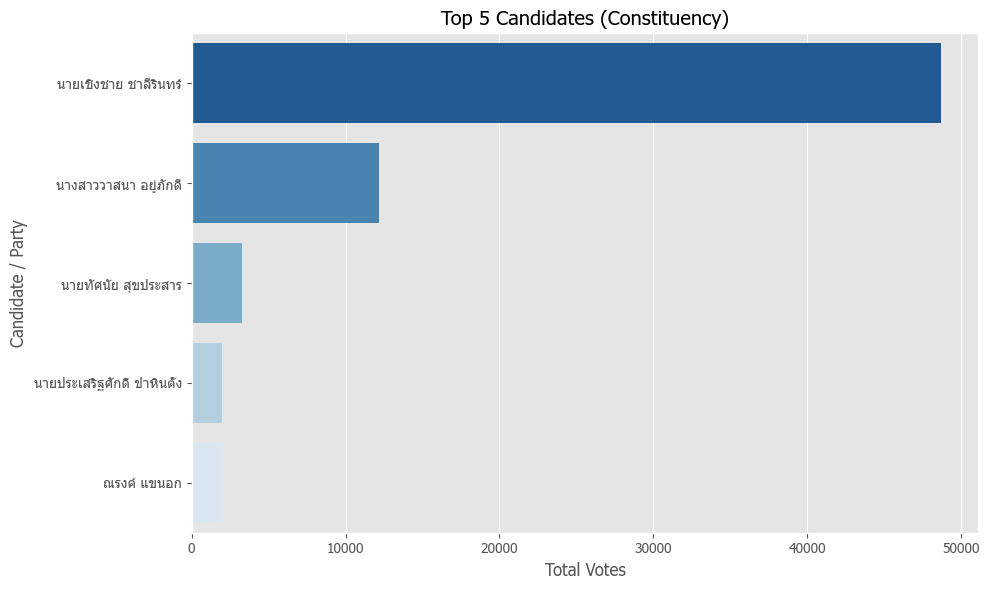

,entity_name,votes
5,นายเชิงชาย ชาลีรินทร์,48700.0
1,นางสาววาสนา อยู่ภักดี,12153.0
3,นายทัศนัย สุขประสาร,3265.0
4,นายประเสริฐศักดิ์ ขำหินตั้ง,1945.0
0,ณรงค์ แขนอก,1944.0


In [18]:
# Aggregate votes by Candidate (entity_name)
candidate_totals = votes_df.groupby('entity_name')['votes'].sum().reset_index()
candidate_totals = candidate_totals.sort_values(by='votes', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(data=candidate_totals, x='votes', y='entity_name', palette='Blues_r')
plt.title('Top 5 Candidates (Constituency)')
plt.xlabel('Total Votes')
plt.ylabel('Candidate / Party')
plt.tight_layout()
plt.show()

display(candidate_totals)

C:\Users\User\AppData\Local\Temp\ipykernel_29856\4207055532.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=party_totals, x='votes', y='entity_name', palette='Oranges_r')


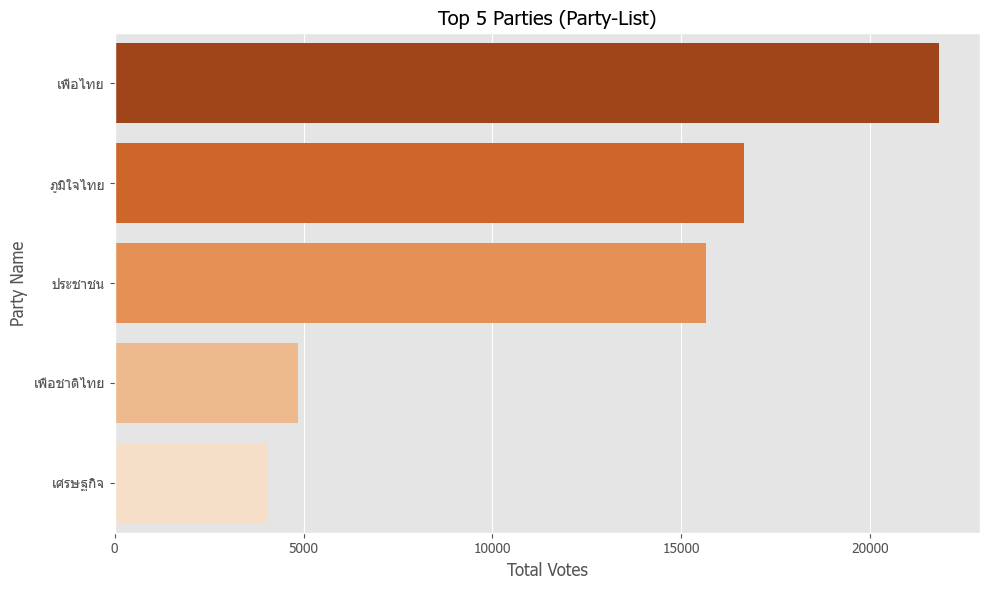

,entity_name,votes
39,เพื่อไทย,21818.0
24,ภูมิใจไทย,16663.0
9,ประชาชน,15666.0
36,เพื่อชาติไทย,4864.0
40,เศรษฐกิจ,4050.0


In [22]:
# Aggregate votes by Party (entity_name)
party_totals = party_votes_df.groupby('entity_name')['votes'].sum().reset_index()
party_totals = party_totals.sort_values(by='votes', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(data=party_totals, x='votes', y='entity_name', palette='Oranges_r')
plt.title('Top 5 Parties (Party-List)')
plt.xlabel('Total Votes')
plt.ylabel('Party Name')
plt.tight_layout()
plt.show()

display(party_totals)

In [ ]:
# Find the top 2 candidates to calculate the margin
top_2 = candidate_totals.head(2).reset_index(drop=True)
if len(top_2) >= 2:
    winner_votes = top_2.loc[0, 'votes']
    runner_up_votes = top_2.loc[1, 'votes']
    margin = winner_votes - runner_up_votes
    margin_pct = (margin / total_present) * 100
    
    print(f"Winning Candidate: {top_2.loc[0, 'entity_name']} ({winner_votes:,} votes)")
    print(f"Runner-up: {top_2.loc[1, 'entity_name']} ({runner_up_votes:,} votes)")
    print(f"Margin of Victory: {margin:,} votes ({margin_pct:.2f}% of total voters)")
    
    if margin_pct < 5.0:
        print("Insight: This was a highly competitive 'Battleground' constituency!")
    else:
        print("Insight: This constituency is a 'Stronghold' for the winning candidate.")

Winning Candidate: นายเชิงชาย ชาลีรินทร์ (48,700.0 votes)
Runner-up: นางสาววาสนา อยู่ภักดี (12,153.0 votes)
Margin of Victory: 36,547.0 votes (47.04% of total voters)
Insight: This constituency is a 'Stronghold' for the winning candidate.


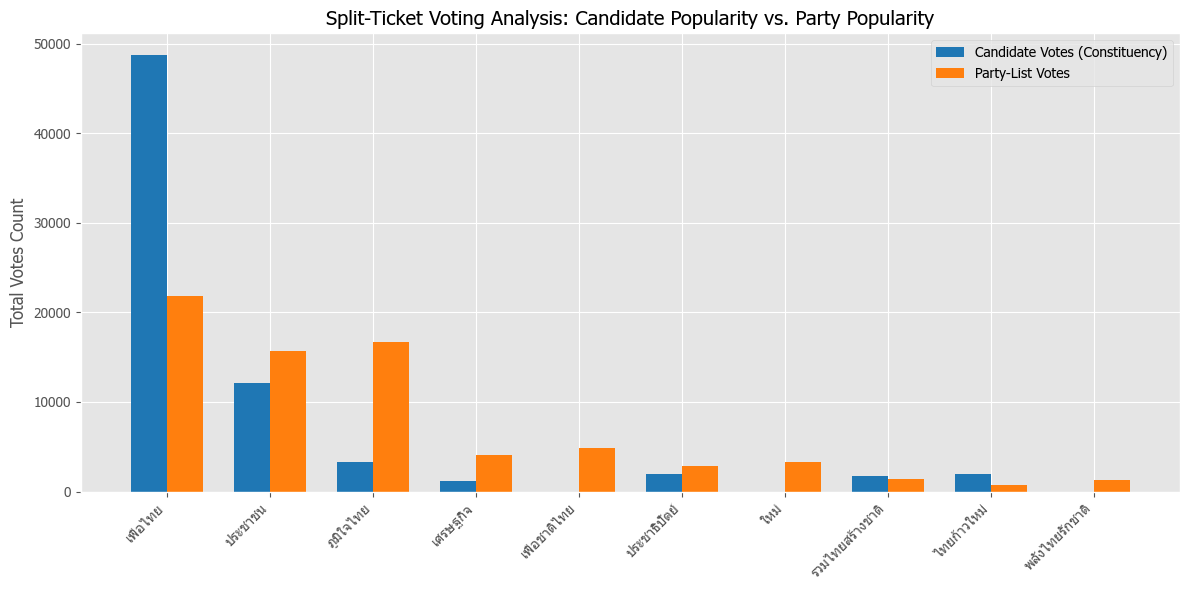

--- Split Voting Insights ---
Positive Vote_Gap (+): Voters chose the Candidate, but picked a different Party on the 2nd ballot.
Negative Vote_Gap (-): Voters chose the Party, but picked a different Candidate on the 1st ballot.



,Party,Candidate_Votes,Party_List_Votes,Vote_Gap
39,เพื่อไทย,48700.0,21818.0,26882.0
9,ประชาชน,12153.0,15666.0,-3513.0
24,ภูมิใจไทย,3265.0,16663.0,-13398.0
40,เศรษฐกิจ,1121.0,4050.0,-2929.0
36,เพื่อชาติไทย,0.0,4864.0,-4864.0
11,ประชาธิปัตย์,1944.0,2795.0,-851.0
45,ใหม่,0.0,3316.0,-3316.0
28,รวมไทยสร้างชาติ,1758.0,1430.0,328.0
47,ไทยก้าวใหม่,1945.0,704.0,1241.0
22,พลังไทยรักชาติ,0.0,1293.0,-1293.0


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 1. Calculate Constituency Votes by Party
# In 5_18_votes, entity_name is the Candidate, so we group by their party_name
candidate_by_party = votes_df.groupby('party_name')['votes'].sum().reset_index()
candidate_by_party.rename(columns={'party_name': 'Party', 'votes': 'Candidate_Votes'}, inplace=True)

# 2. Calculate Party-List Votes by Party
# In 5_18_party_vote, we previously merged the party name into entity_name
party_list = party_votes_df.groupby('entity_name')['votes'].sum().reset_index()
party_list.rename(columns={'entity_name': 'Party', 'votes': 'Party_List_Votes'}, inplace=True)

# 3. Merge the two datasets together based on the Party name
comparison_df = pd.merge(candidate_by_party, party_list, on='Party', how='outer').fillna(0)

# Calculate the difference (Gap)
comparison_df['Vote_Gap'] = comparison_df['Candidate_Votes'] - comparison_df['Party_List_Votes']

# 4. Sort to find the Top 10 most relevant parties for visualization
comparison_df['Total_Combined'] = comparison_df['Candidate_Votes'] + comparison_df['Party_List_Votes']
top_10_parties = comparison_df.sort_values('Total_Combined', ascending=False).head(10)

# 5. Plotting the Comparison (Grouped Bar Chart)
x = np.arange(len(top_10_parties['Party']))
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, top_10_parties['Candidate_Votes'], width, label='Candidate Votes (Constituency)', color='#1f77b4')
rects2 = ax.bar(x + width/2, top_10_parties['Party_List_Votes'], width, label='Party-List Votes', color='#ff7f0e')

# Add text, labels, and title
ax.set_ylabel('Total Votes Count')
ax.set_title('Split-Ticket Voting Analysis: Candidate Popularity vs. Party Popularity')
ax.set_xticks(x)
ax.set_xticklabels(top_10_parties['Party'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

# 6. Display the Data Table to see the exact gap
display_cols = ['Party', 'Candidate_Votes', 'Party_List_Votes', 'Vote_Gap']
print("--- Split Voting Insights ---")
print("Positive Vote_Gap (+): Voters chose the Candidate, but picked a different Party on the 2nd ballot.")
print("Negative Vote_Gap (-): Voters chose the Party, but picked a different Candidate on the 1st ballot.\n")
display(top_10_parties[display_cols])

In [26]:
# 2. Polling Station Size Clustering (Urban vs Rural proxy)
print("\n--- Insight: Voting Preference by Station Size ---")

# Create size categories based on eligible voters (33% percentiles)
station_df['station_size'] = pd.qcut(station_df['eligible_voters'], q=3, labels=['Small', 'Medium', 'Large'])

# Merge size data with party votes
party_with_size = pd.merge(
    party_votes_df, 
    station_df[['station_code', 'station_size']], 
    on='station_code', 
    how='inner'
)

# See which party dominates which station size
size_preference = party_with_size.groupby(['station_size', 'entity_name'], observed=True)['votes'].sum().reset_index()
# Filter for top 3 parties overall to keep it readable
top_3_parties = party_totals.head(3)['entity_name'].tolist()
size_preference_filtered = size_preference[size_preference['entity_name'].isin(top_3_parties)]

# Pivot for easy viewing
pivot_size = size_preference_filtered.pivot(index='station_size', columns='entity_name', values='votes')
display(pivot_size)


--- Insight: Voting Preference by Station Size ---


entity_name,ประชาชน,ภูมิใจไทย,เพื่อไทย
station_size,,,
Small,3946.0,1922.0,5642.0
Medium,6469.0,3191.0,7765.0
Large,6510.0,12335.0,9275.0
